In [1]:
%reload_ext autoreload
%autoreload 2

In [4]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn.loss_fn.score_matching import build_score_matching_loss
from probjax.nn.loss_fn.sliced_score_matching import build_sliced_score_matching_loss
from probjax.nn.loss_fn.denoising_score_matching import build_denoising_score_matching_loss

from probjax.nn import MLP


# Target score

Here we have a simple mixture Gaussian target score

In [5]:
d = 1
mu1 = -2.0 * jnp.ones((d,))
mu2 = 2.0* jnp.ones((d,))
sigma = 0.5* jnp.ones((d,))

@jax.grad
def target_score(x):
    logpdf1 = jax.scipy.stats.norm.logpdf(x, mu1, sigma) + jnp.log(0.5)
    logpdf2 = jax.scipy.stats.norm.logpdf(x, mu2, sigma) + jnp.log(0.5)
    logpdf = jax.scipy.special.logsumexp(jnp.stack([logpdf1, logpdf2], axis=0), axis=0)
    return logpdf.sum()

def sample(key, n):
    key1, key2 = jax.random.split(key)
    n1, n2 = n//2, n-n//2
    x1 = jax.random.normal(key1, (n1,d))* sigma + mu1
    x2 = jax.random.normal(key2, (n2,d))* sigma + mu2
    return jnp.concatenate([x1, x2], axis=0)


## Score matching

This indirectly minimizes the l2 norm between the target score and the ScoreModel only using samples

In [ ]:

class ScoreModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.mlp = MLP([d,50,50, 50,d], rngs=rngs)

    def __call__(self, x, *args, **kwargs):
        return self.mlp(x)



Choose on of the cells to try it out

In [52]:
# Score matching loss
model = ScoreModel(d, nnx.Rngs(0))
params = nnx.state(model, nnx.Param)
loss_fn = build_score_matching_loss(model)

In [58]:
# Sliced score matching loss
model = ScoreModel(d, nnx.Rngs(0))
params = nnx.state(model, nnx.Param)
loss_fn = build_sliced_score_matching_loss(model, num_slices=1)

In [ ]:
# Denoising score matching loss
model = ScoreModel(d, nnx.Rngs(0))
params = nnx.state(model, nnx.Param)
loss_fn = build_denoising_score_matching_loss(model, std=0.01, control_variate=True)

In [59]:
import optax

optimizer = optax.adam(5e-4)
opt_state = optimizer.init(params)


@jax.jit
def update(params,opt_state, *args, **kwargs):
    loss, grads = jax.value_and_grad(loss_fn)(params, *args, **kwargs)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, opt_state

In [60]:
key = jax.random.PRNGKey(1)

In [61]:

losses = []
for i in range(2000):
    l = 0.
    for j in range(10):
        key, subkey, loss_key = jax.random.split(key,3)
        xs = jax.jit(sample, static_argnums=1)(subkey, 1000)
        times = jnp.ones_like(xs)

        loss, params, optimizer = update(params,opt_state, xs, rng=loss_key)
        l += loss / 10

    losses += [float(l)]

nnx.update(model, params)

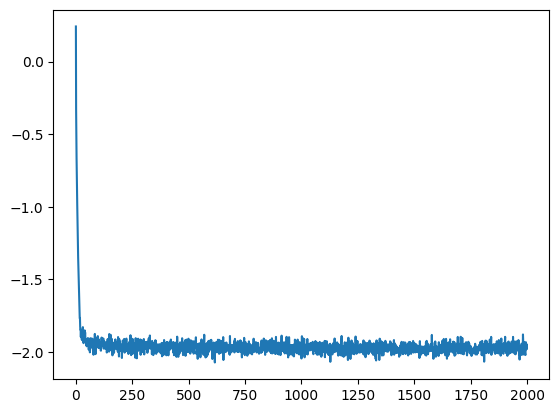

In [62]:
plt.plot(losses)

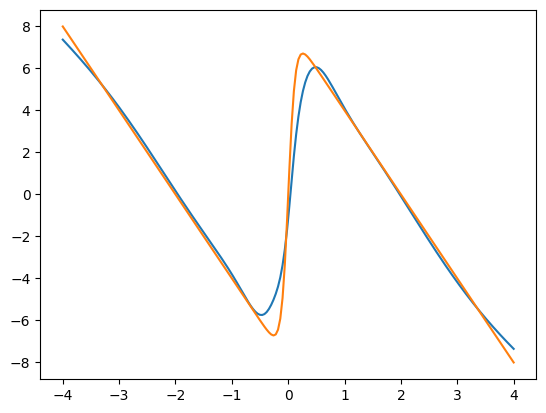

In [64]:

import matplotlib.pyplot as plt

if d == 1:
    x_test = jnp.linspace(-4,4,200)[:,None]
    y = model(x_test)
    y_true = target_score(x_test)
    plt.plot(x_test, y)
    plt.plot(x_test, y_true)
else:
    samples_test = sample(key, 1000)
    y = model(times, samples_test)
    y_true = target_score(samples_test)
    loss = jnp.mean((y - y_true)**2)
    print(loss)
